# Heteroscedasticidad
### Econometría II
**Alejandro Mosiño** — Universidad de Guanajuato

In [ ]:
# Ejecutar solo la primera vez
# install.packages(c("tidyverse", "lmtest", "sandwich", "whitestrap"))

## Datos y modelo MCO

Usamos los datos de gasto en alimentos (`food_exp`) e ingreso (`income`) para estimar el modelo de regresión simple:

$$
\text{food\_exp}_i = \beta_1 + \beta_2 \, \text{income}_i + u_i
$$

In [1]:
library(tidyverse)
library(lmtest)
library(sandwich)
library(whitestrap)

datos <- read.csv("../data/E201--food.csv", sep = "\t")

m1 <- lm(food_exp ~ income, data = datos)
summary(m1)

── Attaching core tidyverse packages 
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Please cite as: 

Lopez, J. (2020), White's test and Bootstrapped White's test under the methodology of Jeong, J., Lee, K. (1999) package version 0.0.1



Call:
lm(formula = food_exp ~ income, data = datos)

Residuals:
     Min       1Q   Median       3Q 
-223.025  -50.816   -6.324   67.879 
     Max 
 212.044 

Coefficients:
            Estimate Std. Error
(Intercept)   83.416     43.410
income        10.210      2.093
            t value Pr(>|t|)    
(Intercept)   1.922   0.0622 .  
income        4.877 1.95e-05 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1

Residual standard error: 89.52 on 38 degrees of freedom
Multiple R-squared:  0.385,	Adjusted R-squared:  0.3688 
F-statistic: 23.79 on 1 and 38 DF,  p-value: 1.946e-05


## Detección gráfica

Guardamos el cuadrado de los residuales y observamos si su dispersión cambia con el ingreso.

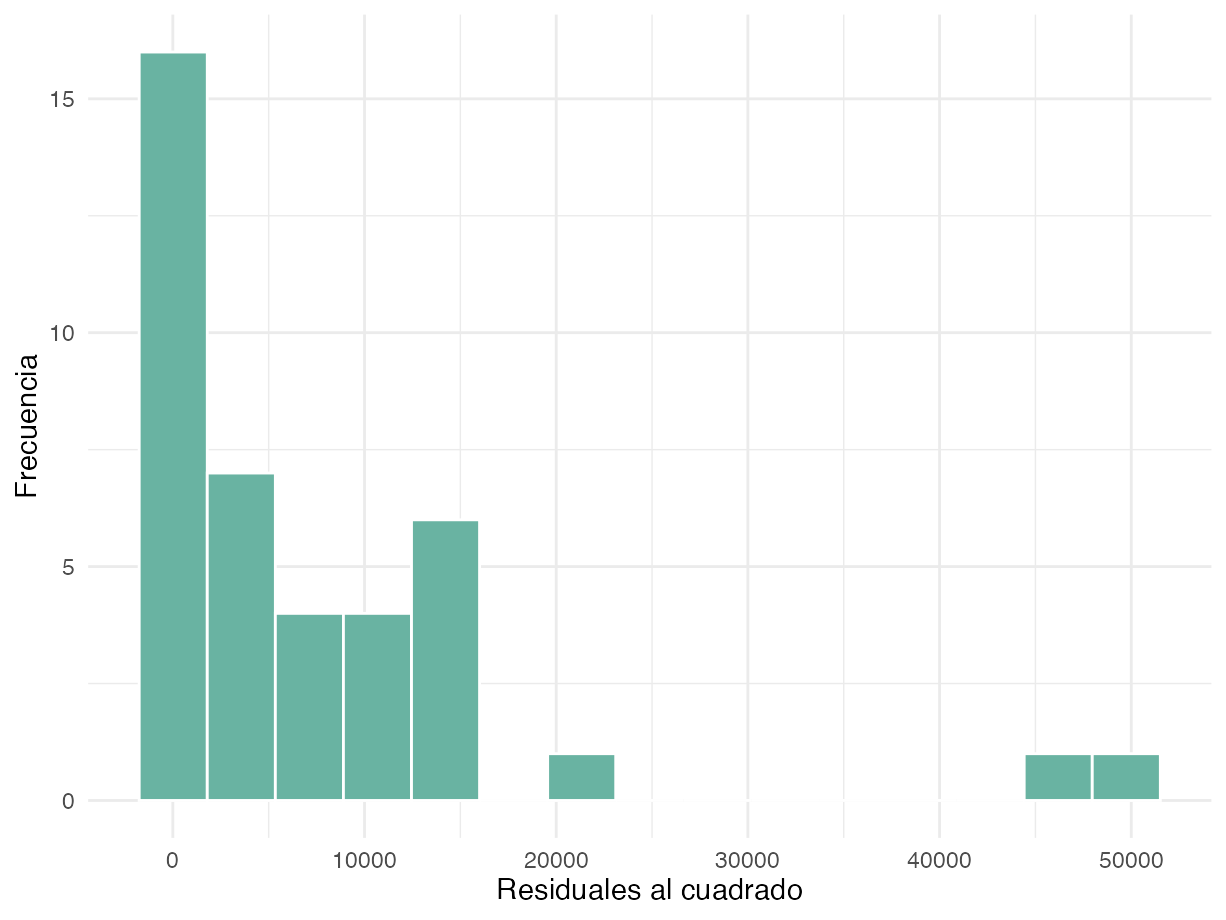

In [8]:
datos$e2 <- residuals(m1)^2

ggplot(datos, aes(x = e2)) +
  geom_histogram(fill = "#69b3a2", color = "white", bins = 15) +
  labs(x = "Residuales al cuadrado", y = "Frecuencia") +
  theme_minimal()

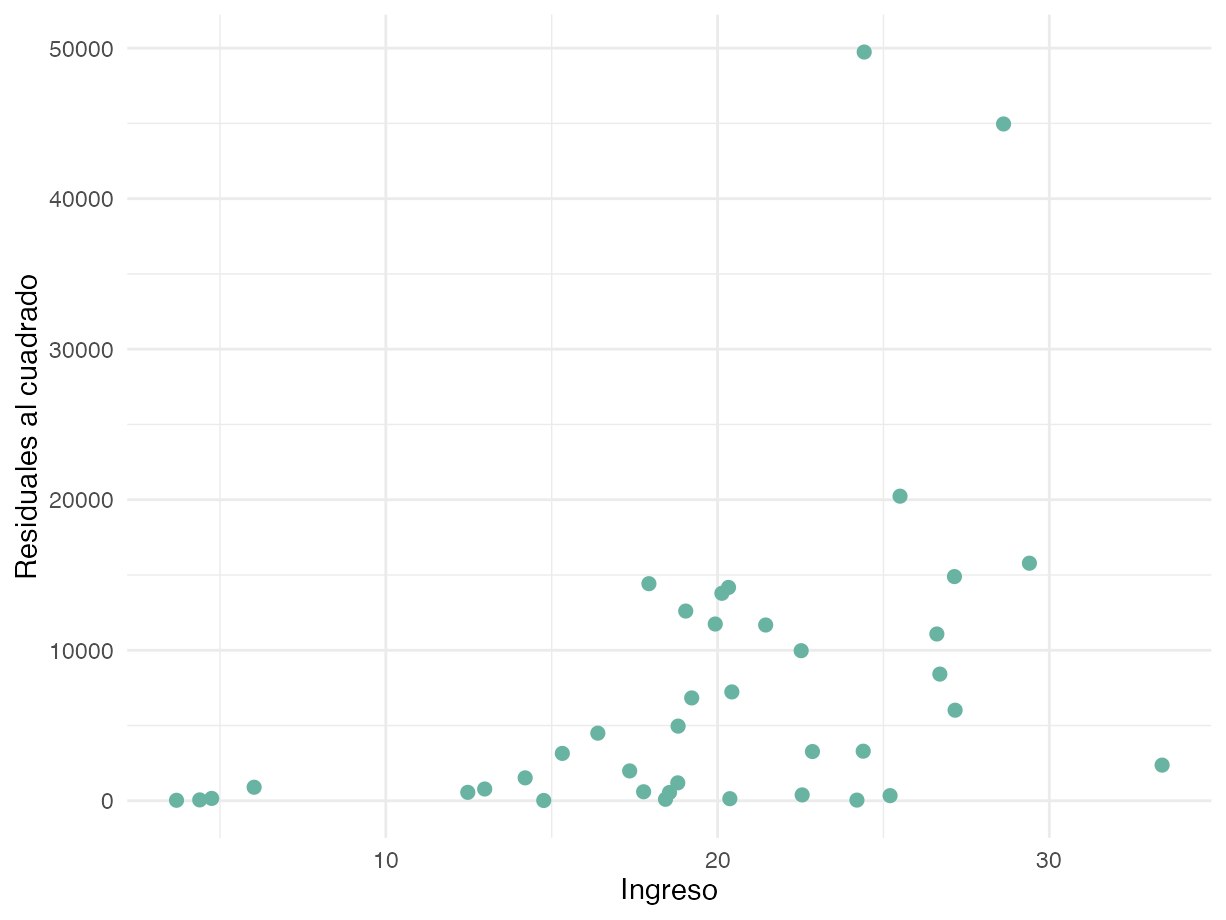

In [7]:
ggplot(datos, aes(x = income, y = e2)) +
  geom_point(color = "#69b3a2", size = 2) +
  labs(x = "Ingreso", y = "Residuales al cuadrado") +
  theme_minimal()

## Prueba de Breusch-Pagan

$$
H_0: \sigma_i^2 = \sigma^2 \qquad H_1: \sigma_i^2 = h(\alpha_1 + \alpha_2 \, \text{income}_i)
$$

Paso a paso: regresamos $e_i^2$ sobre las variables explicativas y calculamos $LM = n R^2$.

In [9]:
aux_bp <- lm(e2 ~ income, data = datos)
n <- nobs(aux_bp)
R2 <- summary(aux_bp)$r.squared

LM_bp <- n * R2
qchisq(0.05, df = 1, lower.tail = FALSE)
pchisq(LM_bp, df = 1, lower.tail = FALSE)

[1] 0.006579112

Con la librería `lmtest`:

In [11]:
bptest(m1, studentize = TRUE)


	studentized Breusch-Pagan test

data:  m1
BP = 7.3844, df = 1, p-value =
0.006579


## Prueba de White

$$
H_0: \sigma_i^2 = \sigma^2 \ \forall i \qquad H_1: \sigma_i^2 \neq \sigma_j^2 \ \text{para algún } i \neq j
$$

Paso a paso: agregamos el cuadrado del regresor a la regresión auxiliar.

In [12]:
aux_wh <- lm(e2 ~ income + I(income^2), data = datos)
LM_wh <- nobs(aux_wh) * summary(aux_wh)$r.squared

qchisq(0.05, df = 2, lower.tail = FALSE)
pchisq(LM_wh, df = 2, lower.tail = FALSE)

[1] 0.02287892

Con la librería `whitestrap`:

In [13]:
white_test(m1)

White's test results

Null hypothesis: Homoskedasticity of the residuals
Alternative hypothesis: Heteroskedasticity of the residuals
Test Statistic: 7.56
P-value: 0.022879

## Prueba de Goldfeld-Quandt

$$
H_0: \sigma_1^2 = \sigma_2^2 \qquad H_1: \sigma_1^2 \neq \sigma_2^2
$$

Paso a paso: estimamos el modelo por separado en cada grupo y comparamos varianzas.

In [14]:
datos <- datos[order(datos$income), ]

aux_poor <- lm(food_exp ~ income, data = datos, subset = 1:20)
aux_rich <- lm(food_exp ~ income, data = datos, subset = 21:40)

GQ <- sigma(aux_rich)^2 / sigma(aux_poor)^2
pf(GQ, aux_rich$df.residual, aux_poor$df.residual, lower.tail = FALSE)

[1] 0.00459643

Con la librería `lmtest`:

In [15]:
gqtest(m1)


	Goldfeld-Quandt test

data:  m1
GQ = 3.6148, df1 = 18, df2 = 18,
p-value = 0.004596
alternative hypothesis: variance increases from segment 1 to 2


## Corrección: MCGF con $\alpha$ conocida

Si suponemos $\sigma_i^2 \propto \text{income}_i^2$, el MCGF consiste en **transformar** el modelo dividiendo entre $\sqrt{\text{income}_i^2}$ y estimar por MCO el modelo transformado.

In [16]:
w <- sqrt(1 / datos$income^2)
y_tilde <- datos$food_exp * w
c_tilde <- w
x_tilde <- datos$income * w

m1_mcgf <- lm(y_tilde ~ c_tilde + x_tilde - 1)
summary(m1_mcgf)


Call:
lm(formula = y_tilde ~ c_tilde + x_tilde - 1)

Residuals:
    Min      1Q  Median      3Q 
-9.2423 -2.5664 -0.2214  3.4069 
    Max 
 7.2566 

Coefficients:
        Estimate Std. Error t value
c_tilde   76.270     12.004   6.354
x_tilde   10.612      1.024  10.367
        Pr(>|t|)    
c_tilde 1.86e-07 ***
x_tilde 1.24e-12 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.048 on 38 degrees of freedom
Multiple R-squared:  0.944,	Adjusted R-squared:  0.9411 
F-statistic: 320.5 on 2 and 38 DF,  p-value: < 2.2e-16


Una forma equivalente, y más práctica, es **ponderar** la varianza directamente con `weights` en `lm()` (esto es, mínimos cuadrados ponderados, MCP):

In [17]:
m2_mcgf <- lm(food_exp ~ income, data = datos, weights = 1 / income^2)
summary(m2_mcgf)


Call:
lm(formula = food_exp ~ income, data = datos, weights = 1/income^2)

Weighted Residuals:
    Min      1Q  Median      3Q 
-9.2423 -2.5664 -0.2214  3.4069 
    Max 
 7.2566 

Coefficients:
            Estimate Std. Error
(Intercept)   76.270     12.004
income        10.612      1.024
            t value Pr(>|t|)    
(Intercept)   6.354 1.86e-07 ***
income       10.367 1.24e-12 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.048 on 38 degrees of freedom
Multiple R-squared:  0.7388,	Adjusted R-squared:  0.7319 
F-statistic: 107.5 on 1 and 38 DF,  p-value: 1.24e-12


## Corrección: MCGF con $\alpha$ estimada

Estimamos $\alpha$ a partir de $\ln(e_i^2) = \alpha_1 + \alpha_2 \ln(\text{income}_i) + v_i$, y transformamos el modelo con ese $\alpha$ estimado.

In [18]:
aux_mcgf <- lm(log(e2) ~ log(income), data = datos)
alpha2 <- coef(aux_mcgf)[2]

w2 <- sqrt(1 / datos$income^alpha2)
y_tilde2 <- datos$food_exp * w2
c_tilde2 <- w2
x_tilde2 <- datos$income * w2

m2_mcgf_manual <- lm(y_tilde2 ~ c_tilde2 + x_tilde2 - 1)
summary(m2_mcgf_manual)


Call:
lm(formula = y_tilde2 ~ c_tilde2 + x_tilde2 - 1)

Residuals:
    Min      1Q  Median      3Q 
-5.4694 -1.5680 -0.1261  2.2368 
    Max 
 4.1695 

Coefficients:
         Estimate Std. Error t value
c_tilde2  76.0538     9.7135    7.83
x_tilde2  10.6335     0.9715   10.95
         Pr(>|t|)    
c_tilde2 1.91e-09 ***
x_tilde2 2.62e-13 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.472 on 38 degrees of freedom
Multiple R-squared:  0.9523,	Adjusted R-squared:  0.9498 
F-statistic: 379.7 on 2 and 38 DF,  p-value: < 2.2e-16


De forma equivalente, con `weights`:

In [19]:
m3_mcgf <- lm(food_exp ~ income, data = datos, weights = 1 / income^alpha2)
summary(m3_mcgf)


Call:
lm(formula = food_exp ~ income, data = datos, weights = 1/income^alpha2)

Weighted Residuals:
    Min      1Q  Median      3Q 
-5.4694 -1.5680 -0.1261  2.2368 
    Max 
 4.1695 

Coefficients:
            Estimate Std. Error
(Intercept)  76.0538     9.7135
income       10.6335     0.9715
            t value Pr(>|t|)    
(Intercept)    7.83 1.91e-09 ***
income        10.95 2.62e-13 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.472 on 38 degrees of freedom
Multiple R-squared:  0.7592,	Adjusted R-squared:  0.7529 
F-statistic: 119.8 on 1 and 38 DF,  p-value: 2.615e-13


## Corrección: errores estándar robustos de White

In [20]:
coeftest(m1, vcov = vcovHC(m1, type = "HC1"))


t test of coefficients:

            Estimate Std. Error
(Intercept)  83.4160    27.4637
income       10.2096     1.8091
            t value  Pr(>|t|)    
(Intercept)  3.0373  0.004299 ** 
income       5.6436 1.755e-06 ***
---
Signif. codes:  
  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05
  ‘.’ 0.1 ‘ ’ 1
